In [1]:
# import all packages
import pandas as pd
import numpy as np
import glob, os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import math
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm
import geopandas as gpd

### Buildings data

### Surface and Volume from GHSL

In [2]:
# builtarea = ['surface', 'volume']
# reading data from multiple years
def read_Data(path, merged_column_names, builtarea):
    df_merged = pd.DataFrame(columns = ['GEOID'])
    if builtarea == 'surface':
        divideby = 1 # area in sqmeter
    elif builtarea == 'volume':
        divideby = 1 # volume in m^3
    else:
        print('Check input format')
        
    merged_column_names.append(builtarea)
    # print(merged_column_names)
    os.chdir(path)
    for file in glob.glob("*.csv"):
        df = pd.read_csv(file, dtype={'GEOID':str})
        df['TOTALAREA_SQKM'] = df[['ALAND', 'AWATER']].sum(axis=1)/1000000
        df[builtarea] = df['sum']/divideby
        df = df.sort_values(by='GEOID').reset_index(drop=True)
        # print(df.columns)
        print('Shape of the dataframe:', df.shape, 'and Total built area (volume) in squaremeters (m^3): ', df[builtarea].sum())
        df_merged = df_merged.merge(df, on='GEOID', suffixes = ('', file[16:-4]), how = 'outer')

    return df_merged

In [ ]:
surface_path = r'E:\Scripts\data\ghsl\Surface\\'
volume_path = r'E:\Scripts\data\ghsl\Volume\\'

column_names = ['GEOID', 'NAMELSAD', 'sum']

df_surface = read_Data(surface_path, column_names, 'surface')
df_volume = read_Data(volume_path, column_names, 'volume')

Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  21644923940.827446
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  24308169725.54902
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  27090809701.21176
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  30132932830.333332
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  34211558949.564705
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  36204795388.78432
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  37375579106.32157
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  157313248400.5608
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m^3):  173143434872.09802
Shape of the dataframe: (32188, 8

In [4]:
# df_volume.filter(regex=("volume*")).columns # '1714000'
# 168.465656 - 121.339918
# df_volume[['GEOID', 'NAMELSAD', 'volume', 'volume_1990', 'volume_1995', 'volume_2000', 'volume_2010', 'volume_2015', 'volume_2020']]

In [5]:
# To check the consecuate changes in area/ volumne in each 10 yr interval
df_surface['change_80_90'] = (df_surface['surface_1990'] - df_surface['surface'])
df_surface['change_90_00'] = (df_surface['surface_2000'] - df_surface['surface_1990'])
df_surface['change_00_10'] = (df_surface['surface_2010'] - df_surface['surface_2000'])
df_surface['change_10_20'] = (df_surface['surface_2020'] - df_surface['surface_2010'])

df_volume['Vchange_80_90'] = (df_volume['volume_1990'] - df_volume['volume'])
df_volume['Vchange_90_00'] = (df_volume['volume_2000'] - df_volume['volume_1990'])
df_volume['Vchange_00_10'] = (df_volume['volume_2010'] - df_volume['volume_2000'])
df_volume['Vchange_10_20'] = (df_volume['volume_2020'] - df_volume['volume_2010'])

### Non residential buildings data from GHSL for the year 2020

In [ ]:
df_non_res_S = pd.read_csv(r'E:\Scripts\data\ghsl\Non_res_surface\BuiltArea_GHSL_S_nres_2020.csv')
df_non_res_S['GEOID'] = df_non_res_S['GEOID'].astype(str).str.rjust(7, '0')
df_non_res_S.rename(columns = {'sum':'surface_nonRes_2020'}, inplace= True)
df_non_res_S.columns
df_non_res_V = pd.read_csv(r'E:\Scripts\data\ghsl\Non_res_surface\BuiltArea_GHSL_V_nres_2020.csv')
df_non_res_V['GEOID'] = df_non_res_V['GEOID'].astype(str).str.rjust(7, '0')
df_non_res_V.rename(columns = {'sum':'volume_nonRes_2020'}, inplace= True)
df_non_res_V.columns

Index(['STATEFP', 'GEOID', 'NAMELSAD', 'ALAND', 'AWATER',
       'volume_nonRes_2020'],
      dtype='object')

### Merge built are with nonResidential: Find residential only

In [7]:
# Merge surface with volume and non residential
# Here surface refers to total building are: res + non-res
df = df_volume.merge(df_surface[['GEOID','surface', 'surface_1990', 'surface_1995', 'surface_2000', 'surface_2010', 'surface_2015', 'surface_2020',
                                 'change_80_90', 'change_90_00', 'change_00_10', 'change_10_20']], on = 'GEOID')
df = df.merge(df_non_res_S[['GEOID', 'surface_nonRes_2020']], on ='GEOID')
df = df.merge(df_non_res_V[['GEOID', 'volume_nonRes_2020']], on ='GEOID')
df['surface_Res_2020'] = df['surface_2020'] - df['surface_nonRes_2020']
df['volume_Res_2020'] = df['volume_2020'] - df['volume_nonRes_2020']

# Residential height in meter
df['height_building'] = df['volume_2020'] / df['surface_2020']
df['floors'] = df['height_building']// 3.048

## Save the clean data to avoid the merging and combining again and again

# df_selected = df[['GEOID', 'TOTALAREA_SQKM_2020', 'surface', 'surface_1990', 'surface_1995', 'surface_2000', 'surface_2010', 'surface_2015', 'surface_2020',
#                    'surface_nonRes_2020','surface_Res_2020', 'volume', 'volume_1990', 'volume_1995', 'volume_2000', 'volume_2010', 'volume_2015', 'volume_2020', 'volume_nonRes_2020',
#                    'Vchange_80_90', 'Vchange_90_00', 'Vchange_00_10', 'Vchange_10_20', 'change_80_90', 'change_90_00', 'change_00_10', 'change_10_20']]

# df_selected.to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\area_vol_clean\GHSL_AREA_VOL_cleaned.csv')

In [8]:
df[['NAMELSAD','surface_2020', 'volume_2020','surface_nonRes_2020','surface_Res_2020','volume_nonRes_2020', 'volume_Res_2020']].describe()/1000

,surface_2020,volume_2020,surface_nonRes_2020,surface_Res_2020,volume_nonRes_2020,volume_Res_2020
count,32.188000,3.218800e+01,32.188000,32.188000,32.188000,3.218800e+01
mean,1161.165003,7.801103e+03,167.222297,993.942705,1415.702965,6.385400e+03
std,5407.612948,4.723404e+04,1004.410381,4457.359925,10144.140057,3.765335e+04
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,77.677229,2.041917e+02,0.000000,74.532750,0.000000,1.967935e+02
50%,222.437198,7.008990e+02,6.718000,209.095184,20.547347,6.494306e+02
75%,740.101875,3.436813e+03,60.105079,663.202121,319.110929,2.991041e+03
max,331180.621741,3.428746e+06,68106.108655,276088.304039,668324.365039,2.760422e+06


In [9]:
df[df['volume_2020']/df['surface_2020'] >= 3][['NAMELSAD','surface_2020', 'volume_2020','surface_nonRes_2020','surface_Res_2020']].sort_values(by = 'surface_2020')

,NAMELSAD,surface_2020,volume_2020,surface_nonRes_2020,surface_Res_2020
918,Tolsona CDP,2.000000e+00,6.000000e+00,0.000000e+00,2.000000e+00
8446,River Forest town,4.309612e+03,2.168891e+04,0.000000e+00,4.309612e+03
27992,Santa Cruz CDP,7.516384e+03,3.173614e+04,3.150706e+02,7.201314e+03
32165,Villa de Sabana comunidad,8.198067e+03,5.068002e+04,0.000000e+00,8.198067e+03
8376,North Crows Nest town,8.229643e+03,5.842759e+04,0.000000e+00,8.229643e+03
...,...,...,...,...,...
27958,San Antonio city,1.840882e+08,1.296802e+09,3.058379e+07,1.535045e+08
18854,New York city,2.125018e+08,2.713595e+09,2.421353e+07,1.882883e+08
1226,Phoenix city,2.422298e+08,1.983561e+09,3.930931e+07,2.029205e+08
27207,Houston city,2.811221e+08,2.278736e+09,6.810611e+07,2.130160e+08


In [10]:
print("Number of missing values in built area data: ===")
df.isna().sum().sum()

Number of missing values in built area data: ===


132

### Read places geometry from shapefile

In [ ]:
os.environ['USE_PYGEOS'] = '0'
# Import places map
places_US = gpd.read_file(r'E:\Scripts\data\tigerline_shapefiles\all_places\compiled.shp')
print('Total no of places in the US:===')
print(places_US.shape)

# Exclude states that do not have consistent data for roadways
places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]
print('No of places in the 50 states:===')
print(places_50_states.shape)

Total no of places in the US:===
(32188, 17)
No of places in the 50 states:===
(31262, 17)


### Join surface volume with geometry

In [12]:
df_with_geom = places_50_states.merge(df[['GEOID', 'surface_2020','surface_Res_2020', 'surface_nonRes_2020', 'volume_2020', 'volume_nonRes_2020', 'volume_Res_2020',
                                          'height_building', 'floors']], on = 'GEOID')
df_with_geom.columns
df_with_geom = df_with_geom.to_crs('EPSG:9311')
print(df.shape, df_with_geom.shape)

(32188, 71) (31262, 25)


In [13]:
# # PLOT THE ATTRIBUTES
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14.27,5.27))
# for ax in axes.flatten():
#     continental_ax = ax          
#     # Set bounds to fit desired areas in each plot for epsg 9311
#     continental_ax.set_xlim(-2257388.37, 2695859.75)
#     continental_ax.set_ylim(-2546944.04, 808080.9)
#     df_with_geom.plot(column = 'change_10_20', 
#              ax=continental_ax,
#              legend = True)

In [14]:
# Area of the place in sqkm
df_with_geom['landAreaSqkm'] = df_with_geom['ALAND']/1000000
# Percent of total area that has buildings
df_with_geom['percent_built_surface'] = df_with_geom['surface_2020'] * 100/df_with_geom['ALAND']

df_with_geom.isna().sum().sum()

6

### Add housing units and age from ACS

In [ ]:
df_YearBuilt = pd.read_csv(r'E:\Scripts\data\housing_data_ACS\HousingDataCleaned.csv', index_col = 0)
df_YearBuilt['GEOID'] = df_YearBuilt['GEOID'].str[9:]

In [16]:
df_YearBuilt[['GEOID','complete_plumbing', 'Year_Built']]

,GEOID,complete_plumbing,Year_Built
0,0100100,100.0,YB_1960_1979
1,0100124,100.0,YB_1960_1979
2,0100460,100.0,YB_1960_1979
3,0100484,100.0,YB_1980_1999
4,0100676,100.0,YB_1980_1999
...,...,...,...
31904,7287638,100.0,YB_1960_1979
31905,7287863,99.1,YB_1960_1979
31906,7288035,98.7,YB_1960_1979
31907,7288121,100.0,YB_1980_1999


In [18]:
df_YearBuilt[df_YearBuilt['GEOID'] == '0652582'][['GEOID', ' !!Total:', 'HUs_occupied', 'HUs_vaccant', 'NAME', 'complete_plumbing', 'Year_Built', 'Percent_Built']]

,GEOID,!!Total:,HUs_occupied,HUs_vaccant,NAME,complete_plumbing,Year_Built,Percent_Built
3061,0652582,21271,20564,707,"Novato city, California",99.6,YB_1960_1979,45.7


In [19]:
df_YearBuilt_selected = df_YearBuilt[['GEOID', ' !!Total:', 'HUs_occupied', 'HUs_vaccant', 'NAME', 'HUs_Total', 'YB_>=_2020', 'YB_2010_2019', 'YB_2000_2009',
               'YB_1980_1999', 'YB_1960_1979', 'YB_1940_1959', 'YB_<=_1939','Year_Built', 'Percent_Built']]

In [20]:
df_YearBuilt.columns

Index(['GEOID', ' !!Total:', 'HUs_occupied', 'HUs_vaccant', 'NAME',
       'HUs_Total', 'YB_>=_2020', 'YB_2010_2019', 'YB_2000_2009',
       'YB_1980_1999', 'YB_1960_1979', 'YB_1940_1959', 'YB_<=_1939',
       'STRUC_detached_1', 'STRUC_attached_1', 'STRUC_apt_2', 'STRUC_apt_3_4',
       'STRUC_apt_5_9', 'STRUC_apt_10_more', 'STRUC_mobile_or_other',
       'HF_Utility_gas', 'HF_Bottled_tank_or_LP gas', 'HF_Electricity',
       'HF_Fueloil_kerosene', 'HF_Coal_coke', 'HF_Others', 'HF_NoFuel',
       'complete_plumbing', 'Year_Built', 'Percent_Built'],
      dtype='object')

### Merge with surface-volume with HUs and age

In [21]:
df_buildings = df_with_geom.merge(df_YearBuilt_selected, on = 'GEOID')
# df_buildings.columns

In [22]:
# get an weighted age for each place 
df_buildings['weighted_avg_age'] = ((2024-1939)*df_buildings['YB_<=_1939'] + (2024-1950)*df_buildings['YB_1940_1959'] + (2024-1970)*df_buildings['YB_1960_1979'] +
                                  (2024-1990)*df_buildings['YB_1980_1999'] + (2024-2004)*df_buildings['YB_2000_2009'] + (2024-2014)*df_buildings['YB_2010_2019'] + 
                                  (2024-2022)*df_buildings['YB_>=_2020'])/100

df_buildings[['STATEFP', 'NAMELSAD','YB_>=_2020','YB_2010_2019', 'YB_2000_2009', 'Year_Built', 'Percent_Built', 'weighted_avg_age']].isna().sum()

STATEFP               0
NAMELSAD              0
YB_>=_2020          489
YB_2010_2019        489
YB_2000_2009        489
Year_Built          489
Percent_Built       489
weighted_avg_age    489
dtype: int64

### Import population and attributes data from depopulation study

In [ ]:
df_population = pd.read_csv(r'E:\Scripts\data\population\forecasted_trend.csv', index_col  = 0)
df_population['GEOID'] = df_population['GEOID'].astype(str).str.rjust(7,'0')

df_attributes = pd.read_csv(r'E:\Scripts\data\population\df_attributes.csv', index_col  = 0)
df_attributes['GEOID'] = df_attributes['GEOID'].astype(str).str.rjust(7,'0')

df_pop_attr = df_population.merge(df_attributes[['GEOID', 'REGION', 'city type', 'weighted_HU_density_sqmi',
                                                 'ua-to-place allocation factor_max', 'population_ua_min',
                                                 'population_ua_max', 'median_income']], on = 'GEOID')

In [24]:
df_attributes.shape, df_population.shape

((31908, 33), (31617, 58))

In [25]:
df_attributes.columns

Index(['STATEFP', 'GEOID', 'NAMELSAD', 'weighted_HU_density_sqmi', 'label',
       'density_km2', 'CensusPop_20', 'future trend from SSP 1',
       'future trend from SSP 2', 'future trend from SSP 3',
       'future trend from SSP 4', 'future trend from SSP 5', 'REGION',
       'DIVISION', 'tt_2_work_place', 'no_veh', 'veh_1', 'veh_2_or+',
       'GEOID_place', 'GEOID_cbsa', 'cbsa20-to-place allocation factor',
       'tt_2_work', 'GEOID_', 'Urban area (2022)_count',
       'population_place_sum', 'ua-to-place allocation factor_min',
       'ua-to-place allocation factor_max', 'population_ua_min',
       'population_ua_max', 'city type', 'median_income', 'veh 1+',
       'veh_<=_1'],
      dtype='object')

In [26]:
df_population[(df_population['ssp42020'] -df_population['CensusPop_20']) > 0][['NAMELSAD', 'CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 
                                                                               'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']]

,NAMELSAD,CensusPop_20,ssp22020,ssp22030,ssp22040,ssp22050,ssp22060,ssp22070,ssp22080,ssp22090,ssp22100
89,West Blocton town,1217,1225.018133,1171.142351,1106.233408,1039.292918,979.340961,928.365265,878.364895,836.323534,813.242878
103,Coffee Springs town,206,208.023567,205.311713,198.584845,189.825234,180.106608,170.365040,157.668422,145.820692,132.991004
123,Oak Hill town,14,14.982006,13.076625,12.118604,10.186573,9.199236,8.206570,7.208573,7.144612,6.135955
330,Haleburg town,112,113.013370,112.114153,108.247648,104.289976,100.346082,97.371079,93.364991,89.330720,84.303547
482,Chunchula CDP,195,197.009336,195.092797,189.169319,181.231705,173.293557,165.347943,154.397925,144.415775,134.420293
...,...,...,...,...,...,...,...,...,...,...,...
31016,Steuben village,122,123.016960,117.143314,109.266512,102.308442,97.350560,92.361022,87.369705,81.362021,76.306206
31402,Waukau CDP,302,305.010415,313.972637,318.907328,319.833751,321.753213,323.666253,323.565127,318.478747,309.408176
31408,Wiota CDP,71,72.009070,69.067762,64.115024,60.132432,56.147155,51.170257,46.170541,42.147682,37.131860
31583,Owl Creek CDP,4,4.953087,5.181235,5.181235,4.953087,4.953087,4.953087,4.953087,4.953087,4.953087


In [27]:
df_population[['ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080', 'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 
                'ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060','ssp42070', 'ssp42080', 'ssp42090', 
                'ssp42100']] =df_population[['ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080', 'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 
                'ssp12060','ssp12070','ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060', 'ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']].round(0)

In [28]:
# Total population for SSP 2 for each 10 yr interval
print('Total population in millions for 51 states: ===')
df_population[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000

Total population in millions for 51 states: ===


CensusPop_20    249.755152
ssp22020        250.994894
ssp22030        271.282461
ssp22040        289.394468
ssp22050        305.168689
ssp22060        320.539042
ssp22070        334.443090
ssp22080        344.689154
ssp22090        350.775271
ssp22100        353.489975
dtype: float64

### Merge buildings with population

In [29]:
building_with_pop_all = df_buildings.merge(df_pop_attr[['GEOID', 'State', 'REGION', 'ua-to-place allocation factor_max', 'population_ua_min',
                                                    'population_ua_max','label', 'future trend from SSP 2', 'CensusPop_20', 'city type','weighted_HU_density_sqmi','median_income',
                                                   'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080',
                                                   'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 
                                                   'ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060',
                                                   'ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']], on = 'GEOID', how='left')

In [30]:
building_with_pop_all[building_with_pop_all['GEOID'].str.startswith('214800')][['GEOID', 'NAMELSAD','CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050']]
# 2010 Census
# Louisville/Jefferson County metro government (balance), Kentucky	597337
# 2020 Census
# Louisville city, Kentucky	246161
# Louisville/Jefferson County metro government (balance), Kentucky	386884

# 246161+386884 = 633045

,GEOID,NAMELSAD,CensusPop_20,ssp22020,ssp22030,ssp22040,ssp22050
10251,2148006,Louisville/Jefferson County metro government (...,386884.0,389068.4372,424417.2341,456660.9352,485264.1312
10411,2148000,Louisville city,NaN,NaN,NaN,NaN,NaN


In [31]:
building_with_pop_all.shape, df_buildings.shape, df_population.shape, df_attributes.shape

((31262, 80), (31262, 42), (31617, 58), (31908, 33))

In [32]:
building_with_pop_all[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080','ssp22090','ssp22100', 
                       'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 'ssp12080', 'ssp12090', 'ssp12100','ssp42020', 
                       'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060','ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']].isna().sum().sum()

1189

In [33]:
building_with_pop_all['percentchangeinpop'] = np.abs((building_with_pop_all['ssp42020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20'])

In [34]:
print("Shape of building dataframe", building_with_pop_all.shape[0])
print("No of places within 1% variation in 2020 census population and ssp scenario 2 and 4")
print("ssp2", building_with_pop_all[np.abs((building_with_pop_all['ssp22020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) < 0.01].shape[0])
print("ssp4", building_with_pop_all[np.abs((building_with_pop_all['ssp42020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) < 0.01].shape[0])
print("No of places over 1% variation in 2020 census population and ssp scenario 2 and 4")
print("ssp2", building_with_pop_all[np.abs((building_with_pop_all['ssp22020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) >= 0.01].shape[0])
print("ssp4", building_with_pop_all[np.abs((building_with_pop_all['ssp42020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) >= 0.01].shape[0])
print("No of places over 5% variation in 2020 census population and ssp scenario 2 and 4")
print("ssp2", building_with_pop_all[np.abs((building_with_pop_all['ssp22020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) >= 0.05].shape[0])
print("ssp4", building_with_pop_all[np.abs((building_with_pop_all['ssp42020'] - building_with_pop_all['CensusPop_20'])/building_with_pop_all['CensusPop_20']) >= 0.05].shape[0])

Shape of building dataframe 31262
No of places within 1% variation in 2020 census population and ssp scenario 2 and 4
ssp2 29208
ssp4 30581
No of places over 1% variation in 2020 census population and ssp scenario 2 and 4
ssp2 2010
ssp4 637
No of places over 5% variation in 2020 census population and ssp scenario 2 and 4
ssp2 187
ssp4 176


In [35]:
# excluding cities that varies over 10% in population forecast in 2020 for ssp4
building_with_pop = building_with_pop_all[(building_with_pop_all['percentchangeinpop'] <=.01)]

In [36]:
# building_with_pop[building_with_pop['city type'] == 'not enough data'].head() #shape[0] # ['CensusPop_20'].sum()

In [37]:
building_with_pop.groupby('city type')[['Percent_Built','weighted_HU_density_sqmi']].describe()

Percent_Built                                              \
                        count       mean        std   min     25%     50%   
city type                                                                   
not enough data           8.0  89.600000  19.413397  53.8  90.750  100.00   
periurban              5683.0  42.755780  13.207129  19.3  33.400   39.90   
rural                 17395.0  46.312785  16.434045  19.2  34.700   42.10   
suburban               6857.0  41.337553  12.070528  18.4  32.600   39.00   
urban                   312.0  42.549679  11.208974  20.8  34.775   41.05   

                                weighted_HU_density_sqmi               \
                     75%    max                    count         mean   
city type                                                               
not enough data  100.000  100.0                      0.0          NaN   
periurban         48.900  100.0                   5700.0   560.814497   
rural             53.300  100.0                  17647.0    33.664466   
suburban          47.500  100.0                   6885.0   953.106510   
urban             48.725   90.7                    312.0  6216.890065   

                                                                     \
                         std          min          25%          50%   
city type                                                             
not enough data          NaN          NaN          NaN          NaN   
periurban         691.968261     0.150793   103.031628   278.353508   
rural             106.229703     0.033770     5.570616    14.014080   
suburban          862.292303     0.000000   261.412868   720.320844   
urban            3912.153516  3018.272827  4259.693215  4958.075743   

                                            
                         75%           max  
city type                                   
not enough data          NaN           NaN  
periurban         746.844116   5904.184022  
rural              32.648646   5369.562100  
suburban         1419.115506  10742.379990  
urban            6775.948549  30707.800203

In [38]:
building_with_pop['weighted_HU_density_sqmi'].isna().sum()

37

In [39]:
condition = building_with_pop[' !!Total:'] != 0
building_with_pop.loc[condition,'HU_density_sqmile'] = building_with_pop[' !!Total:'] / (3.86102e-7 * building_with_pop['ALAND'])
building_with_pop.loc[condition,'avg_HU_size_Res_sqm'] = (building_with_pop['volume_Res_2020'] / building_with_pop[' !!Total:']) # measures avg res unit volume

c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [40]:
building_with_pop[['weighted_HU_density_sqmi','HU_density_sqmile','avg_HU_size_Res_sqm']].describe()

,weighted_HU_density_sqmi,HU_density_sqmile,avg_HU_size_Res_sqm
count,30544.000000,30544.000000,30544.000000
mean,402.453100,560.988290,2013.710058
std,957.209693,855.619435,5430.406602
min,0.000000,0.113780,29.581684
25%,10.849760,139.421515,1275.605437
50%,42.721781,340.212967,1668.793796
75%,361.056782,671.694823,2169.058984
max,30707.800203,60328.412114,344299.263434


In [41]:
# building_with_pop[building_with_pop['avg_HU_size_sqm'] >10000][['STATEFP', 'NAMELSAD', 'avg_HU_size_sqm','surface_Res_2020', 'surface_nonRes_2020', 'volume_2020',]]

In [42]:
print(building_with_pop.shape)

(30581, 83)


In [43]:
print('Total NaNs in population and built area:===')
print(building_with_pop[['CensusPop_20', 'ssp22040', 'surface_Res_2020']].isna().sum())
print("Places with no built area:===", building_with_pop[building_with_pop['surface_Res_2020'] == 0].shape[0])
print("Places with zero population in census 2020:===", building_with_pop[building_with_pop['CensusPop_20'] == 0].shape[0])
print("Places with no available population forecast:===", building_with_pop[building_with_pop['ssp22040'].isnull()].shape[0])

Total NaNs in population and built area:===
CensusPop_20        0
ssp22040            0
surface_Res_2020    0
dtype: int64
Places with no built area:=== 0
Places with zero population in census 2020:=== 0
Places with no available population forecast:=== 0


In [44]:
df_YearBuilt[df_YearBuilt['complete_plumbing'] < 50][['GEOID', ' !!Total:', 'HUs_occupied', 'HUs_vaccant', 'NAME', 'complete_plumbing', 'Year_Built', 'Percent_Built']].sort_values(by ='GEOID').tail(20)

,GEOID,!!Total:,HUs_occupied,HUs_vaccant,NAME,complete_plumbing,Year_Built,Percent_Built
944,0285610,42,1,41,"Wiseman CDP, Alaska",0.0,YB_<=_1939,100.0
978,0405970,40,31,9,"Beyerville CDP, Arizona",40.9,YB_1960_1979,100.0
1014,0412150,16,13,3,"Charco CDP, Arizona",27.3,YB_1980_1999,100.0
1044,0416830,27,22,5,"Cowlic CDP, Arizona",0.0,YB_1960_1979,100.0
1150,0438950,16,15,1,"Ko Vaya CDP, Arizona",0.0,YB_1980_1999,100.0
2528,0623630,90,89,1,"Farmington CDP, California",37.3,YB_<=_1939,62.7
3694,0807571,27,14,13,"Bonanza town, Colorado",25.0,YB_1940_1959,100.0
6428,1675970,45,15,30,"Spencer city, Idaho",42.1,YB_2000_2009,63.2
7997,1809352,55,48,7,"Burns City CDP, Indiana",41.7,YB_<=_1939,100.0
9886,2025900,22,22,0,"Garland CDP, Kansas",25.0,YB_2000_2009,75.0


In [45]:
building_with_pop.columns

Index(['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'NAME_x', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'PCICBSA', 'PCINECTA', 'MTFCC', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'surface_2020',
       'surface_Res_2020', 'surface_nonRes_2020', 'volume_2020',
       'volume_nonRes_2020', 'volume_Res_2020', 'height_building', 'floors',
       'landAreaSqkm', 'percent_built_surface', ' !!Total:', 'HUs_occupied',
       'HUs_vaccant', 'NAME_y', 'HUs_Total', 'YB_>=_2020', 'YB_2010_2019',
       'YB_2000_2009', 'YB_1980_1999', 'YB_1960_1979', 'YB_1940_1959',
       'YB_<=_1939', 'Year_Built', 'Percent_Built', 'weighted_avg_age',
       'State', 'REGION', 'ua-to-place allocation factor_max',
       'population_ua_min', 'population_ua_max', 'label',
       'future trend from SSP 2', 'CensusPop_20', 'city type',
       'weighted_HU_density_sqmi', 'median_income', 'ssp22020', 'ssp22030',
       'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090',
     

In [46]:
building_with_pop['per_cap__nonRes_mass_at_2020'] =  building_with_pop['volume_nonRes_2020'] / building_with_pop['CensusPop_20']
building_with_pop['per_cap__total_mass_at_2020'] =  building_with_pop['volume_2020'] / building_with_pop['CensusPop_20']
building_with_pop['per_cap_mass_at_2020'] =  building_with_pop['volume_Res_2020'] / building_with_pop['CensusPop_20']
# building_with_pop['avg_HU_size_sqm_Res'] = building_with_pop['surface_Res_2020'] / building_with_pop['HUs_Total']
stocks_with_pop = building_with_pop[building_with_pop['CensusPop_20'] != 0]
stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'suburban']
print(stocks_with_pop.shape)

(6885, 86)


c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [54]:
building_with_pop.groupby(['city type', 'REGION'])['per_cap_mass_at_2020'].describe().T

city type not enough data                              periurban               \
REGION            Midwest   Northeast         West       Midwest    Northeast   
count           19.000000    1.000000    17.000000   1261.000000  1099.000000   
mean          1026.556063  272.684627   871.543627    881.627129   721.941034   
std            392.876210         NaN   192.555246    864.660112   545.992376   
min            243.171258  272.684627   606.380894    238.619823   115.594476   
25%            802.079463  272.684627   685.760888    616.010243   467.018945   
50%           1119.568966  272.684627   863.430620    785.479286   614.349494   
75%           1326.547701  272.684627   985.282652   1011.949520   812.564623   
max           1546.880733  272.684627  1296.474074  21119.177852  9191.338078   

city type                                     rural                \
REGION            South          West       Midwest     Northeast   
count       2121.000000   1219.000000   6925.000000   1755.000000   
mean         804.399175    895.618025    909.573966    670.525388   
std          562.927066   1091.655496    822.209821   1546.987688   
min           28.487931     66.349832    119.088235     71.229645   
25%          528.535465    585.972767    628.447721    447.896095   
50%          698.175573    770.795601    799.404058    550.267382   
75%          948.018978   1007.694141   1043.235102    689.154141   
max        12245.261029  30589.288557  52962.852288  51192.557570   

city type                                   suburban               \
REGION             South          West       Midwest    Northeast   
count        5804.000000   3163.000000   1626.000000  1781.000000   
mean          927.759011   1061.098399    982.267941   763.026815   
std          4505.645686   2387.093969    684.439153   408.655216   
min           113.335681     12.425720    196.918160    51.856969   
25%           600.640028    596.329391    745.911393   542.101935   
50%           764.251067    859.380875    914.237648   700.160420   
75%           992.847999   1189.297662   1097.285258   905.028447   
max        341691.085869  96508.126872  16530.077208  6791.151376   

city type                                  urban                            \
REGION            South         West     Midwest    Northeast        South   
count       2372.000000  1106.000000   23.000000   133.000000    78.000000   
mean         982.207695   958.418568  685.324138   578.968337   801.938993   
std          810.773369   549.276385  190.362405   271.997055   524.228531   
min          126.350300   122.864201  379.949385   201.868886   167.621899   
25%          655.519875   680.085235  524.899265   443.607012   509.446761   
50%          877.104094   861.386027  694.067532   543.384621   694.314436   
75%         1154.651666  1097.138133  843.904378   665.425927   952.138849   
max        28832.576950  6279.439421  973.855320  2064.924299  3651.692323   

city type               
REGION            West  
count        78.000000  
mean        648.469748  
std         279.547458  
min         290.812907  
25%         453.834252  
50%         603.543760  
75%         733.279031  
max        1914.439710

In [55]:
building_with_pop['city_type_order'] = building_with_pop['city type'].map({'urban': 1, 'suburban': 2, 'periurban': 3, 'rural': 4, 'not enough data': 5})
building_with_pop['REGION_order'] = building_with_pop['REGION'].map({'Northeast': 1, 'Midwest': 2, 'West': 3, 'South': 4})

c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [56]:
data = building_with_pop[building_with_pop['city type'] != 'not enough data']

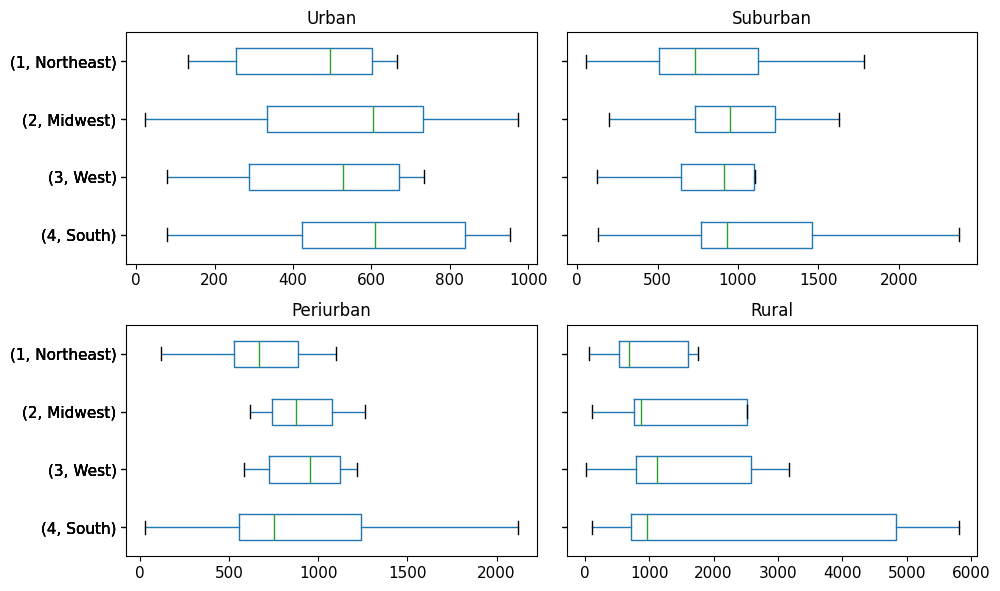

In [59]:
# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

# Boxplot for Value1 and Value2 in the first subplot
data[data['city type'] == 'urban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[0, 0], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 0].set_title('Urban')
axs[0, 0].invert_yaxis()
# # Boxplot for Value1 and Value3 in the second subplot
data[data['city type'] == 'suburban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[0, 1], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 1].set_title('Suburban')
# # Boxplot for Value2 and Value3 in the third subplot
data[data['city type'] == 'periurban'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[1, 0], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 0].set_title('Periurban')
# # Boxplot for all three values in the fourth subplot
data[data['city type'] == 'rural'].groupby(['REGION_order','REGION'])['per_cap_mass_at_2020'].describe().T.boxplot(ax=axs[1, 1], vert=False, sym='+',showfliers=False,
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 1].set_title('Rural')
# Adjust layout
plt.tight_layout()

for ax in fig.axes:
    ax.tick_params(axis='both', which='major', labelsize=11)
    # ax.tick_params(axis='both', which='minor', labelsize=11)
    # ax.axis("off")
    ax.grid(False)
    

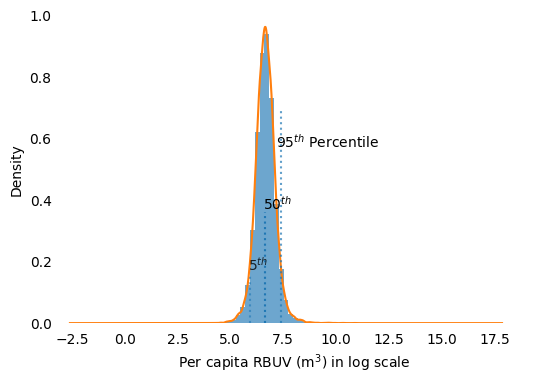

In [ ]:
log_data = np.log(building_with_pop['per_cap_mass_at_2020'])
# sns.histplot(np.log(data['per_cap_mass_at_2020']), alpha = 0.8, color= 'grey', linewidth=0.2)
# citytype_name = ['urban', 'suburban', 'periurban', 'rural']

fig, ax = plt.subplots(figsize = (6,4))

# Plot
# Plot histogram
log_data.plot(kind = "hist", density = True, alpha = 0.65, bins = 45) # change density to true, because KDE uses density
# Plot KDE
log_data.plot(kind = "kde")

# Quantile lines
quant_5, quant_25, quant_50, quant_75, quant_95 = log_data.quantile(0.05), log_data.quantile(0.25), log_data.quantile(0.5), log_data.quantile(0.75), log_data.quantile(0.95)
quants = [[quant_5, 0.6, 0.16], [quant_50, 1, 0.36],  [quant_95, 0.7, 0.7]] # [quant_25, 0.8, 0.26], [quant_75, 0.8, 0.46], 
for i in quants:
    ax.axvline(i[0], alpha = i[1], ymax = i[2], linestyle = ":")


# X
ax.set_xlabel("Per capita RBUV (m$^3$) in log scale")
# Limit x range to 0-4
x_start, x_end = -3, 19
ax.set_xlim(x_start, x_end)
# ax.set_xscale('log')

# Y
ax.set_ylim(0, 1)

# Annotations
ax.text(quant_5-.1, 0.17, "5$^{th}$", size = 10, alpha = 0.8)
# ax.text(quant_25-.13, 0.27, "25th", size = 11, alpha = 0.8)
ax.text(quant_50-.13, 0.37, "50$^{th}$", size = 10, alpha = 1)
# ax.text(quant_75-.13, 0.47, "75th", size = 11, alpha = 0.8)
ax.text(quant_95-.25, 0.57, "95$^{th}$ Percentile", size = 10, alpha =1)

# Overall
ax.grid(False)
# Remove ticks and spines
ax.tick_params(left = False, bottom = False)
for ax, spine in ax.spines.items():
    spine.set_visible(False)
    
plt.show()

### Model comparision Pruned Nonpruned F_test

In [62]:
building_with_pop['per_cap_mass_at_2020'] =  building_with_pop['volume_Res_2020'] / building_with_pop['CensusPop_20']
# building_with_pop['avg_HU_size_sqm_Res'] = building_with_pop['surface_Res_2020'] / building_with_pop['HUs_Total']
stocks_with_pop = building_with_pop[building_with_pop['CensusPop_20'] != 0]
stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'suburban']
print(stocks_with_pop.shape)

infra_col ='surface_Res_2020'
pop_col = 'CensusPop_20'
df = stocks_with_pop.copy()


### ============== PRUNING ============== ###
# Set the threshold to the 90th percentile
threshold = df[pop_col].quantile(0.9)
# Filter the DataFrame to include only points in the to 10%
df_pruned = df[df[pop_col] > threshold]
print(df_pruned.shape)

y = np.log(df[infra_col].astype(float))
x = np.log(df[pop_col].astype(float))

y_pruned = np.log(df_pruned[infra_col].astype(float))
x_pruned = np.log(df_pruned[pop_col].astype(float)) 

m01 = sm.ols("y ~ x", data={"y": y, "x": x}).fit()
m02 = sm.ols("y_pruned ~ x_pruned", data={"y_pruned": y_pruned, "x_pruned": x_pruned}).fit()
anova_results= anova_lm(m01, m02)
print(anova_results)
print('\n')

if anova_results['Pr(>F)'][1] < 0.005:
    print(f"Since {anova_results['Pr(>F)'][1]} < 0.005, difference is significant")
    print("Built seperate models")


(6885, 88)
(689, 88)
   df_resid          ssr  df_diff      ss_diff         F        Pr(>F)
0    6883.0  1144.031709      0.0          NaN       NaN           NaN
1     687.0    55.824445   6196.0  1088.207264  2.161387  1.018318e-34


Since 1.018318461217431e-34 < 0.005, difference is significant
Built seperate models


c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


#### For 2030

In [ ]:
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'E:\Scripts\scripts')
from functions.functions_scaling import find_scale_parameters, find_next_stock, process_stock_at_t

building_clean = building_with_pop.dropna(subset=['CensusPop_20', 'ssp22040', 'surface_Res_2020']).reset_index(drop=True)
building_clean['avg_HU_size_Res_sqm'] = building_clean['volume_Res_2020'] / building_clean[' !!Total:']

# converting building footprint to gross area
building_clean['surface_Res_gross_2020'] = building_clean['surface_Res_2020'] * building_clean['floors'] 
print("Shape of the clean dataset with nonzero values:==", building_clean.shape)


building_clean.groupby('city type')[['volume_Res_2020', 'per_cap_mass_at_2020']].describe().round(2)

Shape of the clean dataset with nonzero values:== (30581, 89)


volume_Res_2020                                        \
                          count         mean           std        min   
city type                                                               
not enough data            37.0    106785.92  4.916970e+04   19210.53   
periurban                5700.0   7540243.11  1.520710e+07    6252.96   
rural                   17647.0    545905.79  7.052359e+05    2353.19   
suburban                 6885.0  17654970.73  5.148114e+07   42324.44   
urban                     312.0  92735393.53  2.654962e+08  182629.08   

                                                                     \
                        25%          50%          75%           max   
city type                                                             
not enough data    79443.96     99446.47    129870.00  2.563235e+05   
periurban        1206827.18   3294764.46   7301336.96  2.899520e+08   
rural             138942.00    288777.56    665803.27  2.547815e+07   
suburban         1772723.83   5430911.78  15473050.99  1.577825e+09   
urban            6738150.60  22373901.43  65074765.85  2.760422e+09   

                per_cap_mass_at_2020                                           \
                               count    mean      std     min     25%     50%   
city type                                                                       
not enough data                 37.0  934.96   334.91  243.17  685.76  936.82   
periurban                     5700.0  825.09   774.14   28.49  542.02  720.67   
rural                        17647.0  918.94  2865.33   12.43  584.14  766.96   
suburban                      6885.0  921.70   661.40   51.86  635.68  837.14   
urban                          312.0  659.93   359.58  167.62  458.66  593.51   

                                     
                     75%        max  
city type                            
not enough data  1175.54    1546.88  
periurban         959.50   30589.29  
rural            1024.31  341691.09  
suburban         1072.84   28832.58  
urban             741.36    3651.69

(30581, 24)
Initial dataframe:====
(30581, 24)
Shape of the dataframe for urban:====
(312, 25)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 25)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     3679.
Date:                Thu, 21 Nov 2024   Prob (F-statistic):          2.38e-162
Time:                        19:57:31   Log-Likelihood:                -127.84
No. Observations:                 280   AIC:                             259.7
Df Residuals:                     278   BIC:                             267.0
Df Model:                           1                                         
Covariance Type:      

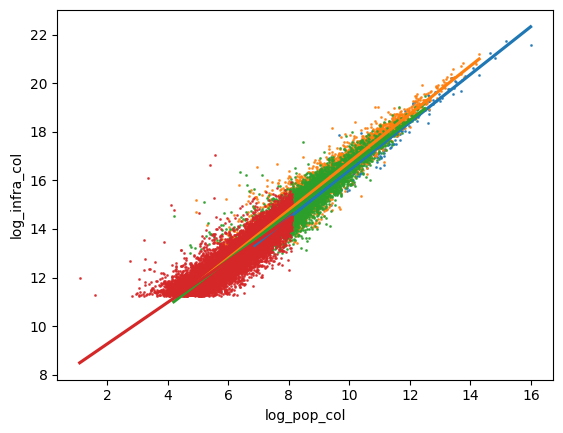

In [64]:
stock_columns_2020 = ['surface_Res_2020', 'surface_Res_gross_2020', 'volume_Res_2020']

current_stock_col = stock_columns_2020[2]
current_pop_col = 'CensusPop_20'
next_pop_col = 'ssp22030'
t = 2030

building_clean['per_cap_mass_at_2020'] =  building_clean[current_stock_col] / building_clean['CensusPop_20']

building_clean['stock_at_t0'] = building_clean['volume_Res_2020']
df_for_analysis = building_clean[['GEOID', 'State', 'NAMELSAD', 'ALAND', 'ua-to-place allocation factor_max', 'population_ua_max', 'weighted_HU_density_sqmi', 'city type', 'median_income',
                                  'CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
                                  'avg_HU_size_Res_sqm','surface_Res_2020','surface_Res_gross_2020', 'volume_Res_2020', 'stock_at_t0']]

df_for_2030 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2030, on ='GEOID')
building_clean = building_clean.merge(df_for_2030, on ='GEOID')
print(building_clean.shape)

In [65]:
df_for_analysis.columns

Index(['GEOID', 'State', 'NAMELSAD', 'ALAND',
       'ua-to-place allocation factor_max', 'population_ua_max',
       'weighted_HU_density_sqmi', 'city type', 'median_income',
       'CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050',
       'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
       'avg_HU_size_Res_sqm', 'surface_Res_2020', 'surface_Res_gross_2020',
       'volume_Res_2020', 'stock_at_t0', 'per_cap_mass_t1',
       'per_cap_mass_at_2030', 'surface_Res_at_2030',
       'HU_density_sqmi_at_2030', 'ua_population_at_2030', 'citytype_at_2030'],
      dtype='object')

#### For 2040 - 2100

(30544, 30)
Initial dataframe:====
(30544, 30)
Shape of the dataframe for urban:====
(325, 30)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(292, 30)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     3922.
Date:                Thu, 21 Nov 2024   Prob (F-statistic):          1.50e-170
Time:                        19:58:48   Log-Likelihood:                -124.47
No. Observations:                 292   AIC:                             252.9
Df Residuals:                     290   BIC:                             260.3
Df Model:                           1                                         
Covariance Type:      

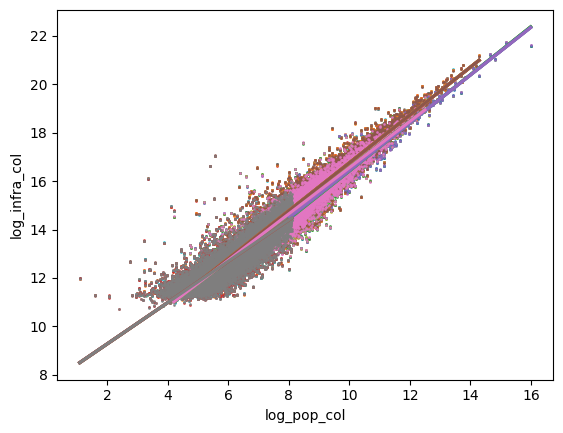

In [67]:
current_stock_col ='surface_Res_at_2030'
current_pop_col = 'ssp22030'
next_pop_col = 'ssp22040'
t = 2040

df_for_2040 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2040, on ='GEOID')
building_clean = building_clean.merge(df_for_2040, on ='GEOID')
print(building_clean.shape)


current_stock_col ='surface_Res_at_2040'
current_pop_col = 'ssp22040'
next_pop_col = 'ssp22050'
t = 2050

df_for_2050 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2050, on ='GEOID')
building_clean = building_clean.merge(df_for_2050, on ='GEOID')
print(building_clean.shape)

current_stock_col ='surface_Res_at_2050'
current_pop_col = 'ssp22050'
next_pop_col = 'ssp22060'
t = 2060

df_for_2060 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2060, on ='GEOID')
building_clean = building_clean.merge(df_for_2060, on ='GEOID')
print(building_clean.shape)

current_stock_col ='surface_Res_at_2060'
current_pop_col = 'ssp22060'
next_pop_col = 'ssp22070'
t = 2070

df_for_2070 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2070, on ='GEOID')
building_clean = building_clean.merge(df_for_2070, on ='GEOID')
print(building_clean.shape)

current_stock_col ='surface_Res_at_2070'
current_pop_col = 'ssp22070'
next_pop_col = 'ssp22080'
t = 2080

df_for_2080 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2080, on ='GEOID')
building_clean = building_clean.merge(df_for_2080, on ='GEOID')
print(building_clean.shape)

current_stock_col ='surface_Res_at_2080'
current_pop_col = 'ssp22080'
next_pop_col = 'ssp22090'
t = 2090

df_for_2090 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2090, on ='GEOID')
building_clean = building_clean.merge(df_for_2090, on ='GEOID')
print(building_clean.shape)

current_stock_col ='surface_Res_at_2090'
current_pop_col = 'ssp22090'
next_pop_col = 'ssp22100'
t = 2100

df_for_2100 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2100, on ='GEOID')
building_clean = building_clean.merge(df_for_2100, on ='GEOID')
print(building_clean.shape)

In [101]:
building_clean['percent change from 2020-2060'] = (building_clean['per_cap_mass_at_2060'] - building_clean['per_cap_mass_at_2020']) / building_clean['per_cap_mass_at_2020']
building_clean['percent change from 2060-2100'] = (building_clean['per_cap_mass_at_2100'] - building_clean['per_cap_mass_at_2060']) / building_clean['per_cap_mass_at_2060']
building_clean['percent change from 2020-2100'] = (building_clean['per_cap_mass_at_2100'] - building_clean['per_cap_mass_at_2020']) / building_clean['per_cap_mass_at_2020']

building_clean['per cap added from 2020-2030'] = (building_clean['per_cap_mass_at_2030'] - building_clean['per_cap_mass_at_2020'])
building_clean['per cap added from 2030-2040'] = (building_clean['per_cap_mass_at_2040'] - building_clean['per_cap_mass_at_2030'])
building_clean['per cap added from 2040-2050'] = (building_clean['per_cap_mass_at_2050'] - building_clean['per_cap_mass_at_2040'])
building_clean['per cap added from 2050-2060'] = (building_clean['per_cap_mass_at_2060'] - building_clean['per_cap_mass_at_2050'])
building_clean['per cap added from 2060-2070'] = (building_clean['per_cap_mass_at_2070'] - building_clean['per_cap_mass_at_2060'])
building_clean['per cap added from 2070-2080'] = (building_clean['per_cap_mass_at_2080'] - building_clean['per_cap_mass_at_2070'])
building_clean['per cap added from 2080-2090'] = (building_clean['per_cap_mass_at_2090'] - building_clean['per_cap_mass_at_2080'])
building_clean['per cap added from 2090-2100'] = (building_clean['per_cap_mass_at_2100'] - building_clean['per_cap_mass_at_2090'])

building_clean_sub = building_clean.assign(**building_clean[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050', 
'per_cap_mass_at_2060', 'per_cap_mass_at_2070', 'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100']].sub(building_clean['per_cap_mass_at_2020'], axis=0).add_prefix('sub_'))

### Age of buildings

In [ ]:
# Define a function that applies another function to each row of the DataFrame
def get_weighted_age(df, function, age_column, current_stock, stock_at_t):
    if stock_at_t[-4:] == '2030':
          t = float(stock_at_t[-4:]) - 2024
    else:
        t = 10

    # Apply function to each row
    result = df.apply(lambda row: function( row[age_column], row[current_stock],row[stock_at_t],t), axis=1)
    return result

# EQUATION: (((df_map['surface_Res_at_2030'] - df_map['volume_Res_2020'])*8 + df_map['volume_Res_2020']*(df_map['weighted_avg_age']+16)) / ((df_map['surface_Res_at_2030'] - df_map['volume_Res_2020']) + df_map['volume_Res_2020']))
def weighted_age_at_t(age_column, current_stock, stock_at_t, t):   
        # print(t)          
        return (((stock_at_t - current_stock)*t/2) + (current_stock*(age_column + t))) / ((stock_at_t - current_stock) + current_stock)

# Apply some_function to each row of the DataFrame
building_clean_sub['weighted_age_2030'] = get_weighted_age(building_clean_sub, weighted_age_at_t, age_column= 'weighted_avg_age', current_stock = 'volume_Res_2020', stock_at_t= 'surface_Res_at_2030')
building_clean_sub['weighted_age_2040'] = get_weighted_age(building_clean_sub, weighted_age_at_t, age_column= 'weighted_age_2030', current_stock = 'surface_Res_at_2030', stock_at_t= 'surface_Res_at_2040')
building_clean_sub['weighted_age_2050'] = get_weighted_age(building_clean_sub, weighted_age_at_t, age_column= 'weighted_age_2040', current_stock = 'surface_Res_at_2040', stock_at_t= 'surface_Res_at_2050')
building_clean_sub['weighted_age_2060'] = get_weighted_age(building_clean_sub, weighted_age_at_t, age_column= 'weighted_age_2050', current_stock = 'surface_Res_at_2050', stock_at_t= 'surface_Res_at_2060')
building_clean_sub['weighted_age_2070'] = get_weighted_age(building_clean_sub, weighted_age_at_t, age_column= 'weighted_age_2060', current_stock = 'surface_Res_at_2060', stock_at_t= 'surface_Res_at_2070')
building_clean_sub['weighted_age_2080'] = get_weighted_age(building_clean_sub, weighted_age_at_t, age_column= 'weighted_age_2070', current_stock = 'surface_Res_at_2070', stock_at_t= 'surface_Res_at_2080')
building_clean_sub['weighted_age_2090'] = get_weighted_age(building_clean_sub, weighted_age_at_t, age_column= 'weighted_age_2080', current_stock = 'surface_Res_at_2080', stock_at_t= 'surface_Res_at_2090')
building_clean_sub['weighted_age_2100'] = get_weighted_age(building_clean_sub, weighted_age_at_t, age_column= 'weighted_age_2090', current_stock = 'surface_Res_at_2090', stock_at_t= 'surface_Res_at_2100')

In [ ]:
building_clean_sub[building_clean_subp['weighted_age_2040'] > 61].shape[0] / building_clean_sub.shape[0], building_clean_sub[building_clean_sub['weighted_age_2050'] > 61].shape[0] / building_clean_sub.shape[0], \
    building_clean_sub[building_clean_sub['weighted_age_2060'] > 61].shape[0] / building_clean_sub.shape[0],\
building_clean_sub[building_clean_sub['weighted_age_2100'] > 61].shape[0] / building_clean_subp.shape[0]

(0.6316788894709272,
 0.8055591932949188,
 0.9146804609743321,
 0.9900471451021478)

In [ ]:
building_clean_sub[building_clean_sub['weighted_age_2050'] > 105].shape[0] *100/ building_clean_sub.shape[0], building_clean_sub[building_clean_sub['weighted_age_2100'] > 105].shape[0] *100/ building_clean_sub.shape[0], \
    building_clean_sub[building_clean_sub['weighted_age_2060'] > 105].shape[0] *100/ building_clean_sub.shape[0]

(0.9036144578313253, 80.97171293871136, 7.749476165531692)

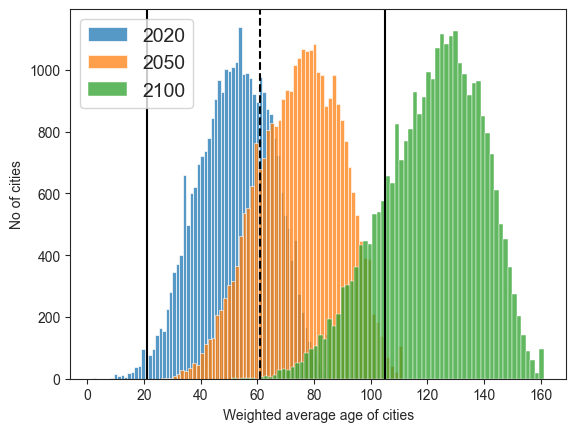

In [ ]:
sns.histplot(building_clean_sub['weighted_avg_age'])
sns.histplot(building_clean_sub['weighted_age_2050'])
sns.histplot(building_clean_sub['weighted_age_2100'])
plt.ylabel('No of cities')
plt.xlabel('Weighted average age of cities') # derived from age of housing units
plt.legend(labels=['2020','2050', '2100'])
plt.axvline(21, color='black')
plt.axvline(61, color='black', linestyle = '--')
plt.axvline(105, color='black')
sns.set_theme(rc={'figure.figsize':(9,7)})

import matplotlib
from matplotlib import rc

# matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['savefig.transparent'] = True
plt.savefig(r'E:\Scripts\outputfiles\figures\weighted_age_buildings0.png', dpi = 300, bbox_inches='tight')

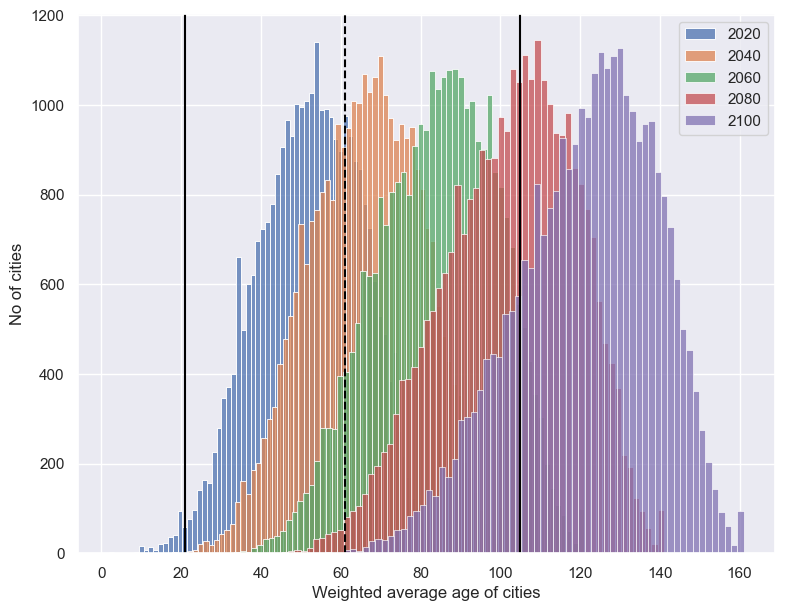

In [ ]:
sns.histplot(building_clean_sub['weighted_avg_age'])
sns.histplot(building_clean_sub['weighted_age_2040'])
sns.histplot(building_clean_sub['weighted_age_2060'])
sns.histplot(building_clean_sub['weighted_age_2080'])
sns.histplot(building_clean_sub['weighted_age_2100'])
plt.ylabel('No of cities')
plt.xlabel('Weighted average age of cities') # derived from age of housing units
plt.legend(labels=['2020','2040', '2060', '2080', '2100'])
plt.axvline(21, color='black')
plt.axvline(61, color='black', linestyle = '--')
plt.axvline(105, color='black')
sns.set_theme(rc={'figure.figsize':(10,6)})

import matplotlib
from matplotlib import rc

# matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['savefig.transparent'] = True
plt.savefig(r'E:\Scripts\outputfiles\figures\weighted_age_buildings.png', dpi = 300, bbox_inches='tight')

In [ ]:
building_clean_sub.groupby(['city type'])[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040',
       'per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070',
       'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100', 'avg_HU_size_Res_sqm',]].quantile([.25, .5, .75])

per_cap_mass_at_2020  per_cap_mass_at_2030  \
city type                                                    
periurban 0.25            542.023907            529.272183   
          0.50            720.667551            706.180825   
          0.75            959.495297            947.876914   
rural     0.25            584.143624            583.150115   
          0.50            766.957681            769.229156   
          0.75           1024.314747           1030.633193   
suburban  0.25            635.677780            634.585947   
          0.50            837.142490            834.139160   
          0.75           1072.843656           1071.844312   
urban     0.25            458.660387            453.412297   
          0.50            593.514478            586.581077   
          0.75            741.360150            733.795161   

                per_cap_mass_at_2040  per_cap_mass_at_2050  \
city type                                                    
periurban 0.25            524.519289            521.998216   
          0.50            700.248254            694.098676   
          0.75            942.747964            945.651951   
rural     0.25            590.432307            600.118467   
          0.50            783.620439            806.857738   
          0.75           1058.874690           1098.436090   
suburban  0.25            636.634879            639.536479   
          0.50            834.878099            839.497822   
          0.75           1076.922190           1084.062193   
urban     0.25            455.873256            454.821294   
          0.50            587.943619            589.737852   
          0.75            733.707991            734.020412   

                per_cap_mass_at_2060  per_cap_mass_at_2070  \
city type                                                    
periurban 0.25            517.248389            512.539925   
          0.50            692.447876            690.456835   
          0.75            947.238772            951.217266   
rural     0.25            607.059171            614.660019   
          0.50            825.461187            846.303301   
          0.75           1132.889627           1173.656637   
suburban  0.25            640.756581            644.398861   
          0.50            843.241051            848.236067   
          0.75           1088.984244           1092.370096   
urban     0.25            452.214940            451.693679   
          0.50            585.618953            581.439274   
          0.75            736.485579            735.615679   

                per_cap_mass_at_2080  per_cap_mass_at_2090  \
city type                                                    
periurban 0.25            509.856262            511.797329   
          0.50            692.500717            699.117409   
          0.75            958.695854            979.151019   
rural     0.25            626.256101            641.649890   
          0.50            876.936745            911.230189   
          0.75           1227.749362           1293.531822   
suburban  0.25            647.083166            652.990381   
          0.50            855.594565            864.288624   
          0.75           1103.649293           1119.503607   
urban     0.25            449.925867            449.431262   
          0.50            578.611800            579.259377   
          0.75            739.673472            745.923072   

                per_cap_mass_at_2100  avg_HU_size_Res_sqm  
city type                                                  
periurban 0.25            516.504891          1288.150031  
          0.50            708.351996          1725.770224  
          0.75           1005.881219          2241.166098  
rural     0.25            660.590556          1219.467681  
          0.50            955.720457          1567.814730  
          0.75           1379.093298          1998.523967  
suburban  0.25            659.898827          1496.459577  


In [ ]:
buildings_perCap = building_clean_sub.rename(columns={'per_cap_mass_at_2020': 'volume_m3_perCap_2020','per_cap_mass_at_2030': 'volume_m3_perCap_2030', 'per_cap_mass_at_2040': 'volume_m3_perCap_2040', 
                            'per_cap_mass_at_2050': 'volume_m3_perCap_2050', 'per_cap_mass_at_2060': 'volume_m3_perCap_2060', 'per_cap_mass_at_2070': 'volume_m3_perCap_2070', 
                            'per_cap_mass_at_2080': 'volume_m3_perCap_2080', 'per_cap_mass_at_2090': 'volume_m3_perCap_2090', 'per_cap_mass_at_2100': 'volume_m3_perCap_2100',})

buildings_perCap[['GEOID', 'NAMELSAD', 'city type','REGION', 'ALAND', 'CensusPop_20','ssp22030', 'ssp22040','ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100', 
                  'volume_m3_perCap_2020', 'volume_m3_perCap_2030', 'volume_m3_perCap_2040', 
                  'volume_m3_perCap_2050', 'volume_m3_perCap_2060', 'volume_m3_perCap_2070', 'volume_m3_perCap_2080', 'volume_m3_perCap_2090',
                  'volume_m3_perCap_2100']].to_csv(r'E:\Scripts\outputfiles\csvs\buildings_perCap_ssp2.csv')